# MOD300 Project 4 report


## Topic 1


### Installing milkyway_plot
git clone --depth=1 https://github.com/henrysky/milkyway_plot.git
cd .\milkyway_plot\
python -m pip install -e .

### Task 1

In [ ]:
from Topic1.Task1 import gen_milkyway

gen_milkyway()

### Task 2

In [ ]:
from Topic1.Task2 import gen_milkyway_sector

print("Generating sectors for various celestial objects:")
print("1. Andromeda Galaxy")
print("2. Omega Centauri (A large collection of stars)")
print("3. Large Magellanic Cloud (Dwarf galaxy)")
print("4. Eagle Nebula")

gen_milkyway_sector("M31", 8800) # Andromeda Galaxy
gen_milkyway_sector("LMC", 3500) # Large Magellanic Cloud
gen_milkyway_sector("M16", 2500)  # Eagle Nebula
omega_centauri = gen_milkyway_sector("NGC 5139", 2500)   # Omega Centauri

### Task 3

In [ ]:
from Topic1.Task3 import plt2rgbarr

print(f"Loading sector image from: {omega_centauri}")

rgb_array = plt2rgbarr(omega_centauri)
print(f"RGB array shape for Omega Centauri sector: {rgb_array.shape}")

### Task 4

The first step in generating categories from the data is to determine what property of the data is the most meaningful. The array we are working with contains a collection of pixels of various colors. 

My first though is that the brightness or "whiteness" of a pixel could be interesting as it means there is a star there and stars have a lot of gravity so there is probably other stuff there as well. Additionally areas of medium brightness could indicate the existence of an object that is reflecting light such as a nebula.

Another interesting property of the data could be the color/hue, stars have different color depending on their size and life-cycle stage so the color data could tell us something about the age and size of objects around the galaxy and might be worth investigating further.

For this assignment we will use the brightness of the pixels to generate the categories. We will create 3 different categories, "dark" "medium" and "bright". To find the brightness of a pixel we are calculating the sum of the rgb values. Based on this sum we assign each pixel a number from 0-2 indicating if it is dark, medium or bright:


$sum < 250$: dark  
$250 <= sum < 400$: medium  
$sum > 400$: bright  


In [ ]:
from Topic1.Task4 import encode_rgb_data_brightness
from matplotlib import pyplot as plt

categories = encode_rgb_data_brightness(rgb_array)
print(f"Created {len(categories)} categories from Omega Centauri sector.")

# Visualize the categories
plt.imshow(categories)
plt.show()

### Task 5

Using K-means clustering on the brightness encoding.

In [ ]:
from Topic1.Task5 import kmeans_clustering

clustered_data = kmeans_clustering(rgb_array, n_clusters=3)

# Reshape clustered data back to image dimensions for visualization
cluster_plot_data = clustered_data.reshape(rgb_array.shape[0], rgb_array.shape[1])

# plot the clustered data
plt.imshow(cluster_plot_data)
plt.title("K-Means Clustering Result")
plt.axis('off')
plt.show()


# k-nn clustering
from Topic1.Task5 import knn_clustering
knn_clustered_data = knn_clustering(rgb_array, categories)
# reshape
knn_cluster_plot_data = knn_clustered_data.reshape(rgb_array.shape[0], rgb_array.shape[1])
plt.imshow(knn_cluster_plot_data)
plt.title("K-NN Clustering Result")
plt.axis('off')
plt.show()

### Task 6

Overimposing the cluster generated by the k-means method over the original image.

In [ ]:
from Topic1.Task6 import overlay_clustered_image

overlay_clustered_image(rgb_array, cluster_plot_data, alpha=0.4)

### Task 7

Now we will repeat task 5 and 6 with different categories. First we tried categorizing the pixels by brightness, this time we will try to use a grey encoding. 

#### Grey Encoding

The difference between this and the brightness encoding is that instead of calculating the sum of the RGB values in each pixel, we first multiply the RGB values with something called standard luminance weights. These weights are based on how the human eye percieves the different colors (Red, Green, Blue). The weights we will be used are [0.299, 0.587, 0.114].

After multiplying the RGB values with the weights we calculate their sum and retrieve only the sums that are over a certain threshold. The result is a map of the objects that appear the brightest to a human eye (But not nessecarily the objectively brightest pixels).

In [ ]:
from Topic1.Task4 import encode_rgb_data_grey

grey_encoding = encode_rgb_data_grey(rgb_array)
print(f"Grey encoding shape: {grey_encoding.shape}")

# Visualize the grey encoding
plt.imshow(grey_encoding, cmap='gray')
plt.title("Grey Encoding Visualization")
plt.axis('off')
plt.show()


In [ ]:
# clustering and overlay

from Topic1.Task5 import knn_clustering
from Topic1.Task6 import overlay_clustered_image

clustered_data_grey = knn_clustering(rgb_array, grey_encoding)
# reshape
cluster_plot_data_grey = clustered_data_grey.reshape(rgb_array.shape[0], rgb_array.shape[1])
plt.imshow(cluster_plot_data_grey)
plt.title("K-NN Clustering Result on Grey Encoding")
plt.axis('off')
plt.show()

# overlay
overlay_clustered_image(rgb_array, cluster_plot_data_grey, alpha=0.4, title="Overlay of K-NN Clustering on Grey Encoding")


We have now tried categorizing by objective brightness and percieved brightness (grey encoding). Finally we will categorize the data based on pixel color. As the rgb array we created already is an array of colors, lets see what happens if we perform unsupervised clustering on it without furter encoding. This time we will use a higher number of clusters to see what happens when the k-means method is told to generate more complex cluster data.

In [ ]:
from Topic1.Task5 import kmeans_clustering

clustered_data_color = kmeans_clustering(rgb_array, n_clusters=8) # using a higher number of clusters this time

# reshape and visualize
cluster_plot_data_color = clustered_data_color.reshape(rgb_array.shape[0], rgb_array.shape[1])
plt.imshow(cluster_plot_data_color)
plt.title("K-Means Clustering Result on RGB Data")
plt.colorbar()
plt.axis('off')
plt.show()

We see that according to the colorbar the starcluster in the middel has a lower value (purple $\approx$ 1.0) than its surroundings (yellow and green $\approx$ 5.0-7.0). This happens because with this method, the labels assigned to the clusters do not mean anything. They are not sorted by brightness or color or anything else, they just represent different colors. This means that the colorbar in the plot is entirely pointless. It has been included by us to demonstrate that it is useless.


In [ ]:
# overlay color clustering over original image
from Topic1.Task6 import overlay_clustered_image

overlay_clustered_image(rgb_array, cluster_plot_data_color, alpha=0.4, title="Overlay of K-Means Clustering on RGB Data")



#### Which category is best?

It depends on what we want to achieve. 

Categorizing by brightness can give us an energy map of the galaxy, as high energy objects glow more and are likely more white than low energy objects, giving them a high RGB sum. Making an energy map this way has its problems because the colors of celestial objects depend on what gasses they are surrounded by. The brightness of a high energy object could be dimmed by a surrounding dust could.

If we care most about how humans percieve the galaxy, the gray encoding is better, as it takes the traits of the human eye into consideration.


If we care about the colors of the different regions the cluster based on the non-encoded rgb data would be the best choice. Similar objects (nebulas, dward stars, normal stars, planets, asteroids, etc) might have similar colors. If this is the case color based clustering can help us identify the locations of similar objects and how many of them exist. Additionally, using the k-means method on RGB data does not require us to label the data, so its easy to quickly make a very large ammount of clusters if we want to preserve the details of the image.


## Topic 2

### Task 1

### Task 2

### Task 3

### Task 4

LSTM prediction of the epidemic evolution.

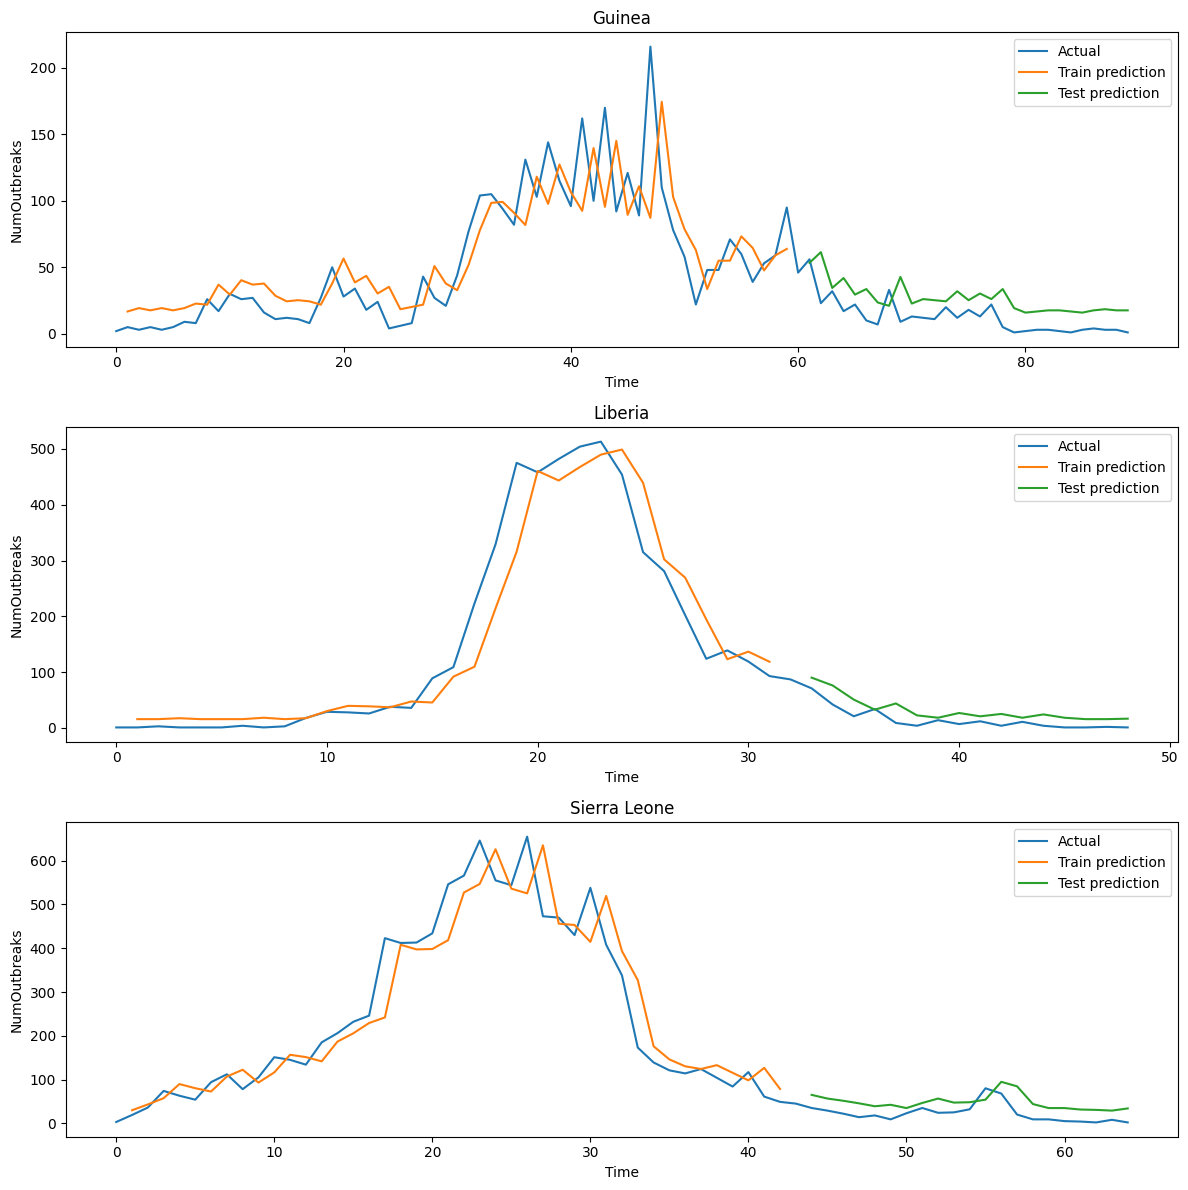

In [3]:
import Topic2.Task4

Topic2.Task4.plot_lstm_results()

### Task 5

## Contribution and Self Reflection

## References